In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

%matplotlib inline

In [13]:
df = pd.read_csv('height-weight.csv')
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


Text(0, 0.5, 'height')

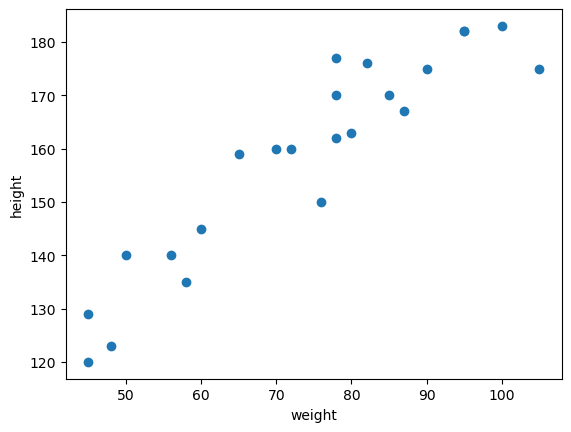

In [14]:
plt.scatter(x=df.Weight, y = df.Height)

plt.xlabel('weight')
plt.ylabel('height')

In [15]:
# correlation to check relationship between them

df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


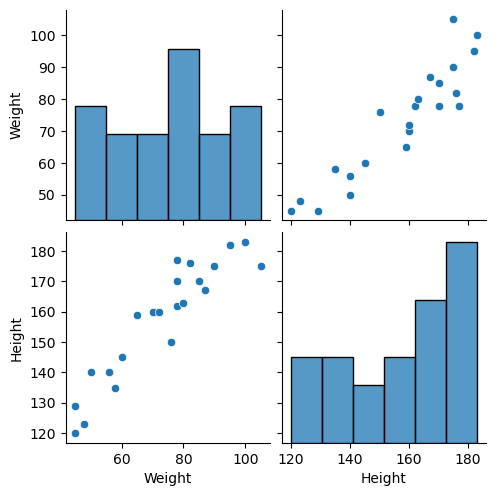

In [16]:
sns.pairplot(data = df)

In [21]:
X =df['Weight']
type(X)

pandas.core.series.Series

In [ ]:
np.array(X).shape # 1 dimensional array no column need to change into 2D array

(23,)

In [23]:
df.head()

X =df[['Weight']] # independent features sould be in dataframe or 2 dimensional array for model tarining as column is mandatory
type(X) # so we used double square brackets to make the series into the dataframe



pandas.core.frame.DataFrame

In [24]:
np.array(X).shape

(23, 1)

In [26]:
y = df['Height'] # dependent feature can be anything series or dataframe as it is 1D feature 

np.array(y).shape

(23,)

In [29]:
# Train and Test Split
from sklearn.model_selection import train_test_split



In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.25, random_state = 42)

In [31]:
X_train.shape

(17, 1)

In [32]:
X_test.shape

(6, 1)

In [33]:
# Standardization
# Z-Score -> mean = 0 and std = 1

# Z-score = (mean - xi)/std

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [35]:
X_train = scaler.fit_transform(X_train)

In [36]:
X_test = scaler.transform(X_test)

In [37]:
# apply machine learing algo

from sklearn.linear_model import LinearRegression

linreg= LinearRegression()

In [38]:
linreg.fit(X_train,y_train)

LinearRegression()

In [ ]:
 # it gives the beta1 value in y_hat = beta0 + beta1*xi where xi is weight variable here,beta0 is intercept, beta1 is co-eff

print('coefficient or slope:  ',linreg.coef_) # 1 unit moment in the x axis leads 17.2982057 unit moments in y axis
 

coefficient or slope:   [17.2982057]


In [43]:

print('intercept:  ',linreg.intercept_)

intercept:   156.47058823529412


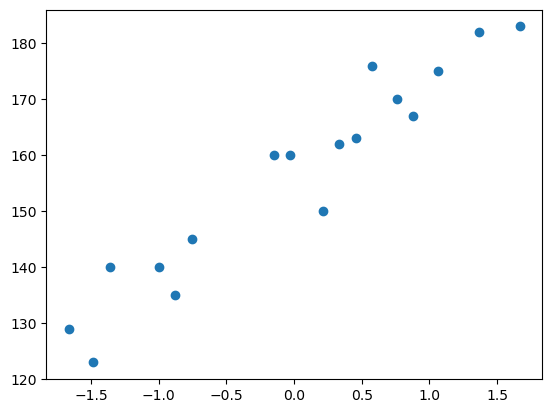

In [44]:
# plot training data plot  best fit Line

plt.scatter(X_train,y_train)

In [ ]:
linreg.predict(X_train)

array([141.30649667, 185.31934779, 162.26499721, 130.82724641,
       180.07972266, 127.68347133, 143.40234673, 153.88159699,
       160.16914715, 132.92309646, 139.21064662, 155.97744705,
       174.84009753, 166.45669731, 169.60047239, 171.69632245,
       164.36084726])

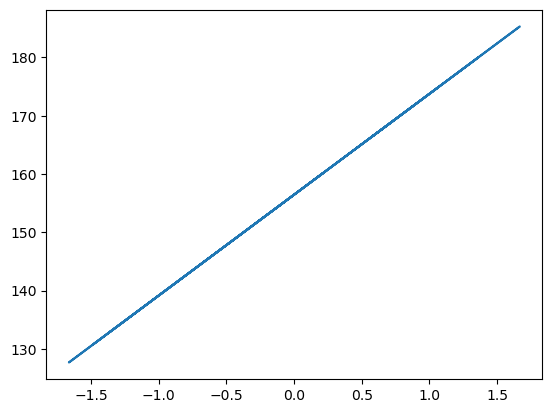

In [47]:
plt.plot(X_train,linreg.predict(X_train))

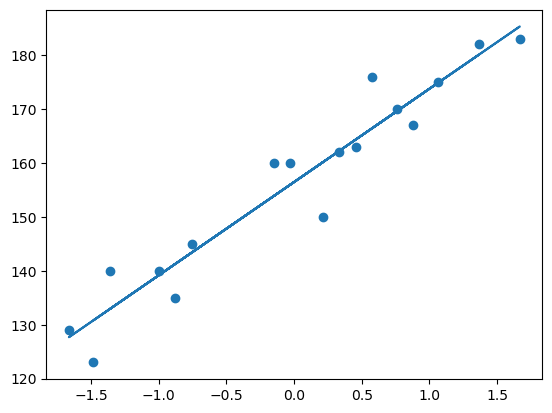

In [48]:
plt.scatter(X_train,y_train)
plt.plot(X_train,linreg.predict(X_train))


## preddiction of test data

predicted height output = intercept +coef_(weights)
y_pred_test = 156.47+17.29(X_test)

In [49]:
## prediction for test data

y_pred = linreg.predict(X_test)

In [53]:
# performance

from sklearn.metrics import mean_absolute_error,mean_squared_error

mse = mean_squared_error(y_test,y_pred)
print(mse)

mae =mean_absolute_error(y_test, y_pred)
print(mae)

rmse= np.sqrt(mse)
print(rmse)

114.84069295228699
9.665125886795005
10.716374991212605


# ## r-squared

##### r^2 = 1- (SSR/SST)

##### r^2 = coeff of determination 
##### ssr = sum of square of residuals
##### sst = total sum of squrres

In [55]:
from sklearn.metrics import r2_score

score = r2_score(y_test,y_pred)
print(score)

0.7360826717981276


In [56]:
# adjusted r^2

1 - (1-score)*(len(y_test)-1)/ (len(y_test)- X_test.shape[1] -1)

0.6701033397476595

In [57]:
# OLS Linear Regression

import statsmodels.api as sm

model = sm.OLS(y_train,X_train).fit()


In [58]:
prediction = model.predict(X_test)

In [59]:
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [60]:
model.summary()

d:\Anaconda\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Tue, 07 Apr 2026   Prob (F-statistic):                       0.664
Time:                        03:03:15   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            17.2982     39.138      0.442      0.664     -65.671     100.267
==============================================================================
Omnibus:                        0.135   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.935   Jarque-Bera (JB):                0.203
Skew:                          -0.166   Prob(JB):                        0.904
Kurtosis:                       2.581   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# prediction for new data

linreg.predict(scaler.transform([[72]]))# scaler transform is a crucial step to standardize the new data before prediction

d:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])